# 02_分类算法-KNN

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本文和大家分享的是关于KNN的内容，K-近邻在大家印象中一定是是一种简单又常用的机器学习算法，常用于分类和回归任务。

具体它是怎么工作的呢？下面娓娓道来。

KNN是一种基于实例的学习方法，也就是说，它**不需要提前训练模型**，而是直接使用所有的训练数据进行预测。

当你有一个新数据点需要分类或预测时，KNN会看看这个新数据点周围最接近的K个数据点，然后根据这些邻居的数据来决定新数据点的类别或预测值。

### 基本步骤

**1. 选择K值**：K代表你要找多少个最近的邻居。K可以是1、3、5等等。K的值会影响结果，通常需要通过试验来找到一个合适的值。

**2. 计算距离**：对于新数据点，计算它到所有训练数据点的距离。常用的距离计算方法是欧几里得距离（就是我们平时说的两点之间的直线距离）。

**3. 找出最近的K个邻居**：根据计算出来的距离，选出距离最近的K个邻居。

**4. 做出预测**：

- **分类任务**：看这K个邻居中，哪个类别出现的次数最多，就把新数据点归为哪个类别。
- **回归任务**：取这K个邻居的数值的平均值，作为新数据点的预测值。

### 举个例子

假设你是一个水果商，有一批水果需要分类成苹果和橙子。

你手上有一些已知的水果数据，包括它们的大小和颜色，比如：

- 水果1：大小中等，颜色红，已知是苹果
- 水果2：大小大，颜色橙，已知是橙子
- 水果3：大小小，颜色红，已知是苹果
- ...

现在来了一颗新的水果，它的大小是中等，颜色是红色。你想知道它是苹果还是橙子。

1. 你选择K=3，表示你要看最接近的3个水果。
2. 计算这颗新水果和所有已知水果的距离。
3. 找出距离最近的3个已知水果。
4. 这3个水果中，如果有2个是苹果，1个是橙子，那么你就可以推测新水果是苹果，因为多数是苹果。

## 理论基础

### 数学原理和公式推理

**1. 距离度量**

KNN的核心思想是根据距离来判断数据点的类别或回归值。常用的距离度量是欧几里得距离。

给定两个点 $x = (x_1, x_2, ..., x_n)$和 $y = (y_1, y_2, ..., y_n)$，它们的欧几里得距离可以表示为：


$$
d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}
$$


其他常用的距离度量包括曼哈顿距离和闵可夫斯基距离等。

**2. 分类任务**

对于分类任务，KNN会根据K个最近邻的类别进行多数表决。

假设我们有一个待分类点 $x$，其K个最近邻点的类别分别为 $y_1, y_2, ..., y_K$，则 $x$的类别 $\hat{y}$由以下公式确定：


$$
\hat{y} = \text{mode}(y_1, y_2, ..., y_K)
$$


其中，mode表示众数，即出现次数最多的类别。

**3. 回归任务**

对于回归任务，KNN会根据K个最近邻点的数值进行平均。

假设我们有一个待预测点 $x$，其K个最近邻点的数值分别为 $y_1, y_2, ..., y_K$，则 $x$的预测值 $\hat{y}$由以下公式确定：


$$
\hat{y} = \frac{1}{K} \sum_{i=1}^{K} y_i
$$


### 算法流程

**步骤1：准备数据**

准备训练数据集 $\{(x_i, y_i)\}_{i=1}^{N}$，其中 $x_i$是第 $i$个数据点的特征向量， $y_i$是第 $i$个数据点的标签或数值。

**步骤2：选择参数K**

选择一个合适的K值。K通常是一个小的正整数，可以通过交叉验证等方法来选择最佳的K值。

**步骤3：计算距离**

对于待预测的点 $x$，计算它到训练集中所有数据点的距离。假设训练集中有N个数据点，距离计算公式为：


$$
d(x, x_i) = \sqrt{\sum_{j=1}^{n} (x_j - x_{ij})^2}
$$


**步骤4：选择K个最近邻**

根据计算出的距离，对所有训练数据点进行排序，选择距离最近的K个数据点。这些点的索引可以表示为 $\{i_1, i_2, ..., i_K\}$。

**步骤5：做出预测**

- 对于分类任务，统计这K个最近邻点的类别频率，选择出现频率最高的类别作为预测结果。


$$
\hat{y} = \text{mode}(y_{i_1}, y_{i_2}, ..., y_{i_K})
$$


- 对于回归任务，计算这K个最近邻点的数值平均值，作为预测结果。


$$
\hat{y} = \frac{1}{K} \sum_{j=1}^{K} y_{i_j}
$$


**步骤6：返回结果**

将预测结果 $\hat{y}$返回给用户。

### 详细推理示例

假设我们有如下二维平面上的训练数据点及其类别：

| 数据点 | 坐标 (x, y) | 类别 |
|-|-|-|
| 点A | (1, 2) | 0 |
| 点B | (2, 3) | 0 |
| 点C | (3, 3) | 1 |
| 点D | (6, 5) | 1 |

现在，我们有一个待分类的新数据点 $x = (3, 2)$，选择K=3。

步骤：

**1. 计算距离**：

- 点A到x的距离：$d(A, x) = \sqrt{(1-3)^2 + (2-2)^2} = \sqrt{4} = 2$
- 点B到x的距离：$d(B, x) = \sqrt{(2-3)^2 + (3-2)^2} = \sqrt{1+1} = \sqrt{2} \approx 1.41$
- 点C到x的距离：$d(C, x) = \sqrt{(3-3)^2 + (3-2)^2} = \sqrt{1} = 1$
- 点D到x的距离：$d(D, x) = \sqrt{(6-3)^2 + (5-2)^2} = \sqrt{9+9} = \sqrt{18} \approx 4.24$

**2. 选择K个最近邻**：

最近的3个邻居是点C、点B和点A。

**3. 做出预测**：

最近邻的类别分别是：1、0、0。多数类别是0，因此预测结果为0。

## 完整案例

我们使用 KNN 算法对著名的鸢尾花（Iris）数据集进行分类，并进行算法优化。

鸢尾花数据集包含150个样本，每个样本有四个特征：花萼长度、花萼宽度、花瓣长度和花瓣宽度。

目标是根据这些特征将鸢尾花分成三类：Setosa、Versicolour和Virginica。

### 步骤1：数据准备和可视化

首先，把数据集使用起来\~

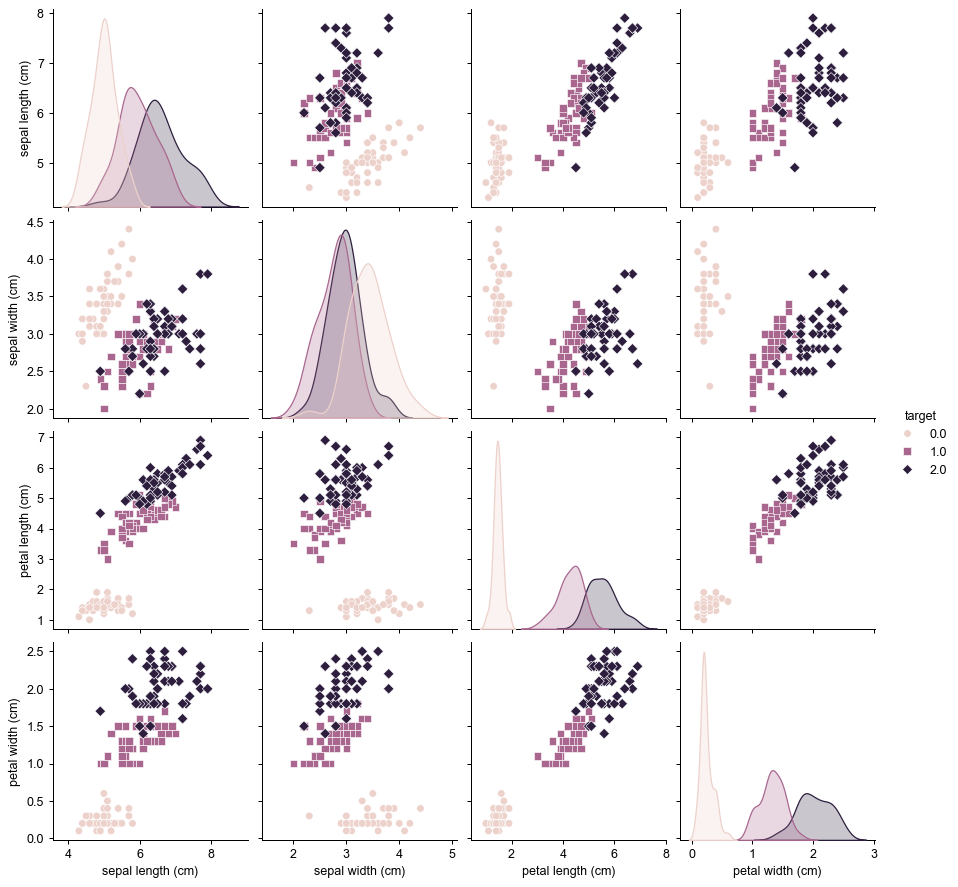

In [2]:
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 加载鸢尾花数据集
iris = datasets.load_iris()
X = iris.data
y = iris.target
df = pd.DataFrame(data=np.c_[X, y], columns=iris.feature_names + ['target'])

# 数据可视化
sns.pairplot(df, hue='target', markers=["o", "s", "D"])
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_024.png)

### 步骤2：数据预处理

在应用KNN之前，我们需要标准化数据，因为KNN对特征的量纲敏感。

In [3]:
# 数据集分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 特征标准化
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### 步骤3：训练KNN模型

选择合适的K值并训练模型。这里，我们通过交叉验证选择最优的K值。

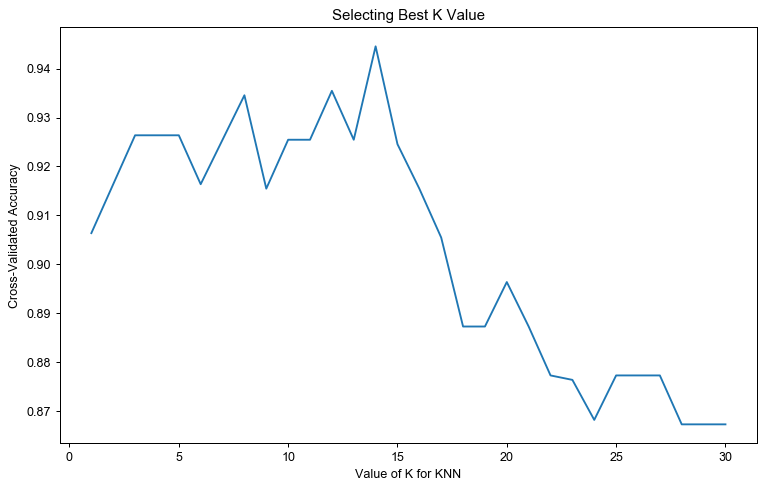

Best K value: 14


In [4]:
from sklearn.model_selection import cross_val_score

# 寻找最佳的K值
k_range = range(1, 31)
k_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=10, scoring='accuracy')
    k_scores.append(scores.mean())

# 可视化K值选择过程
plt.figure(figsize=(10, 6))
plt.plot(k_range, k_scores)
plt.xlabel('Value of K for KNN')
plt.ylabel('Cross-Validated Accuracy')
plt.title('Selecting Best K Value')
plt.show()

# 选择最佳K值
best_k = k_range[np.argmax(k_scores)]
print(f"Best K value: {best_k}")

![原文参考图，当前结果见代码输出](attachments/img_025.png)

### 步骤4：模型训练与评估

使用最佳K值训练KNN模型，并在测试集上进行评估。

In [5]:
# 使用最佳K值训练模型
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

# 模型预测
y_pred = knn.predict(X_test)

# 模型评估
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')
print('Classification Report:')
print(classification_report(y_test, y_pred))

Accuracy: 1.00
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



### 步骤5：优化与可视化

进一步优化KNN模型，并进行预测结果的可视化。

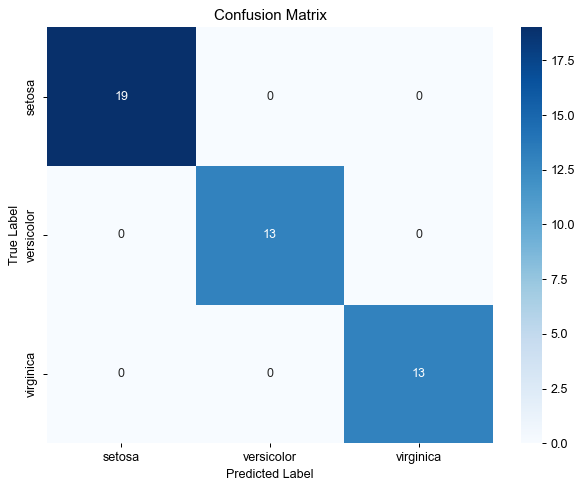

In [6]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# 混淆矩阵
conf_matrix = confusion_matrix(y_test, y_pred)

# 可视化混淆矩阵
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_026.png)

整个以上的步骤，我们实现了一个完整的KNN算法应用案例，包括数据加载、预处理、模型训练、评估和优化。

最后进行了可视化以帮助理解数据分布和模型性能。KNN算法的性能高度依赖于数据标准化和K值的选择，因此这些步骤是关键。

## 模型分析

### KNN 模型优缺点

**优点**

**1. 简单易懂**：KNN是一个非常直观且简单易实现的算法，适合初学者理解和使用。

**2. 无参数模型**：KNN不需要训练过程，只需要保存训练数据即可进行预测。

**3. 适用于多分类问题**：KNN可以很好地处理多分类问题，如鸢尾花数据集中的三个类别。

**4. 灵活性强**：通过调整K值可以控制模型的复杂度，容易进行调优。

**缺点**

**1. 计算复杂度高**：KNN需要计算待预测点与所有训练数据点的距离，数据集较大时计算量非常大。

**2. 内存消耗大**：KNN需要存储所有训练数据，内存消耗较大，尤其是对于大规模数据集。

**3. 对特征尺度敏感**：KNN对特征的尺度非常敏感，因此需要进行数据标准化处理。

**4. 噪声敏感**：KNN对噪声数据敏感，容易受离群点影响。

### 与相似算法的对比

| **对比项** | **决策树** | **KNN** | **支持向量机 (SVM)** |
|-|-|-|-|
| **基本概念** | 递归划分数据空间进行分类或回归 | 通过最近邻样本的标签进行分类或回归 | 通过寻找最佳超平面进行分类 |
| **优点** | 对数据尺度不敏感，不需标准化，易理解和解释 | 简单直观，无需训练，调参容易 | 在高维空间表现好，对噪声不敏感，可处理非线性问题 |
| **缺点** | 易过拟合，对噪声敏感 | 计算复杂度高，内存消耗大，对数据尺度敏感 | 计算复杂度高，对参数和核函数选择敏感 |
| **训练速度** | 快 | 无需训练 | 慢 |
| **预测速度** | 快 | 慢，尤其是大规模数据 | 中等 |
| **适合数据类型** | 结构化数据，适用于小到中等规模数据 | 小规模数据集，特征空间较简单 | 高维数据，特别适用于非线性分类问题 |
| **应用建议** | 适用于需要高可解释性的任务，如决策支持 | 适用于数据量较小、分类边界较简单的问题 | 适用于高维数据、复杂分类任务，如文本分类 |

### 何时使用KNN

**优选KNN的情况**

**1. 小数据集**：数据集较小时，KNN的计算复杂度不高，可以快速计算。

**2. 数据分布较简单**：数据分布较简单且没有明显的噪声时，KNN可以很好地进行分类。

**3. 特征数量较少**：特征数量较少的情况下，KNN的计算效率较高且性能较好。

**4. 初步模型测试**：可以作为基准模型，快速评估数据集的基本情况。

**考虑其他算法的情况**

**1. 大数据集**：数据集较大时，KNN的计算复杂度和内存消耗过高，应考虑其他更高效的算法，如随机森林、SVM等。

**2. 高维数据**：特征数量较多时，KNN的计算效率下降，应考虑降维技术或其他算法，如PCA结合SVM。

**3. 数据尺度不一致**：如果数据特征的尺度差异较大且难以标准化，可以选择对尺度不敏感的算法，如决策树、随机森林。

**4. 需要模型解释性**：如果需要对模型的决策过程进行解释，可以选择易于解释的算法，如决策树。

## 最后

KNN是一种简单直观的算法，适用于小规模、特征数量较少且数据分布较简单的分类或回归任务。

然而，在大规模、高维数据集或数据尺度不一致的情况下，其他算法可能会表现更好。在实际应用中，大家可以根据数据集的具体情况选择最合适的算法，并通过调优和对比来达到最佳效果。